<a href="https://colab.research.google.com/github/rachit2005/Computer-Vision/blob/main/unet_using_snn_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahwagih/retina-blood-vessel")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'retina-blood-vessel' dataset.
Path to dataset files: /kaggle/input/retina-blood-vessel


In [2]:
! pip install kaggle
!pip install snntorch
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 4.8 MB/s eta 0:00:00


In [3]:
!kaggle datasets download -d abdallahwagih/retina-blood-vessel

Dataset URL: https://www.kaggle.com/datasets/abdallahwagih/retina-blood-vessel
License(s): apache-2.0
  0% 0.00/32.9M [00:00<?, ?B/s]
100% 32.9M/32.9M [00:00<00:00, 1.64GB/s]


In [4]:
! unzip retina-blood-vessel.zip

Archive:  retina-blood-vessel.zip
  inflating: Data/test/image/0.png   
  inflating: Data/test/image/1.png   
  inflating: Data/test/image/10.png  
  inflating: Data/test/image/11.png  
  inflating: Data/test/image/12.png  
  inflating: Data/test/image/13.png  
  inflating: Data/test/image/14.png  
  inflating: Data/test/image/15.png  
  inflating: Data/test/image/16.png  
  inflating: Data/test/image/17.png  
  inflating: Data/test/image/18.png  
  inflating: Data/test/image/19.png  
  inflating: Data/test/image/2.png   
  inflating: Data/test/image/3.png   
  inflating: Data/test/image/4.png   
  inflating: Data/test/image/5.png   
  inflating: Data/test/image/6.png   
  inflating: Data/test/image/7.png   
  inflating: Data/test/image/8.png   
  inflating: Data/test/image/9.png   
  inflating: Data/test/mask/0.png    
  inflating: Data/test/mask/1.png    
  inflating: Data/test/mask/10.png   
  inflating: Data/test/mask/11.png   
  inflating: Data/test/mask/12.png   
  inflating: Dat

In [11]:
import matplotlib.pyplot as plt
import os

base_path = "Data/train"
mask_path = base_path + "/mask"
image_path = base_path + "/image"

print(f"total len: {len(os.listdir(image_path))}")
print(f"sample images: {os.listdir(image_path)[:5]}")

total len: 80
sample images: ['7.png', '78.png', '11.png', '9.png', '42.png']


In [12]:
from torch import nn
from torch.utils.data import DataLoader , Dataset
import numpy as np
import pandas as pd

In [13]:
images_files = sorted([os.path.join(image_path, file) for file in os.listdir(image_path)])
masks_files = sorted([os.path.join(mask_path, file) for file in os.listdir(mask_path)])

In [14]:
df = pd.DataFrame({"image":images_files , "mask":masks_files})

print(len(df))
print(df.shape)
print(df.head())

80
(80, 2)
                     image                    mask
0   Data/train/image/0.png   Data/train/mask/0.png
1   Data/train/image/1.png   Data/train/mask/1.png
2  Data/train/image/10.png  Data/train/mask/10.png
3  Data/train/image/11.png  Data/train/mask/11.png
4  Data/train/image/12.png  Data/train/mask/12.png


In [15]:
from PIL import Image
from torchvision import transforms

image_size = 256

transform = transforms.Compose([
    transforms.Resize((image_size , image_size)),
    transforms.ToTensor(),
])

class UNETDataset(Dataset):
    def __init__(self , df , transform=transform):
      self.df = df
      self.transform = transform

    def __len__(self):
      return len(self.df)

    def __getitem__(self, index):
      image = self.df.iloc[index , 0]
      mask = self.df.iloc[index , 0]

      image = Image.open(image).convert("RGB")
      mask = Image.open(mask).convert("L")

      if self.transform:
        image = self.transform(image)
        mask = self.transform(mask)

      return image , mask

In [16]:
dataset = UNETDataset(df)

print(dataset[0])

(tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0039, 0.0039, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0275, 0.0275, 0.0314,  ..., 0.0275, 0.0275, 0.0314],
         [0.0275, 0.0275, 0.0314,  ..., 0.0275, 0.0275, 0.0314],
         [0.0275, 0.0314, 0.0314,  ..., 0.0157, 0.0157, 0.0157]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0039, 0.0039, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0275, 0.0275, 0.0314,  ..., 0.0275, 0.0275, 0.0275],
         [0.0275, 0.0275, 0.0275,  ..., 0.0275, 0.0275, 0.0275],
         [0.0275, 0.0275, 0.0275,  ..., 0.0157, 0.0157, 0.0157]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0039, 0.0039, 0.0000,  ..., 0.0000, 0.0000, 0

# Unet Model

In [17]:
import torch
from snntorch import surrogate
import snntorch as snn


class conv_block(nn.Module):
  def __init__(self , in_channels , out_channels , beta=0.9):
    super().__init__()

    spike_grad = surrogate.atan()

    self.conv_layer = nn.Sequential(
        nn.Conv2d(in_channels=in_channels , out_channels=out_channels , kernel_size=3 , padding=1),
        snn.Leaky(beta=beta, spike_grad=spike_grad , init_hidden=True),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels=out_channels , out_channels=out_channels , kernel_size=3 , padding=1),
        snn.Leaky(beta=beta, spike_grad=spike_grad , init_hidden=True),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )

  def forward(self , x):
    return self.conv_layer(x)

  def reset_state(self):
        """Resets the membrane potential (state) of the internal neurons."""
        for layer in self.conv_layer:
            if isinstance(layer, snn.Leaky):
                layer.reset_hidden()


class Encoder(nn.Module):
  def __init__(self , in_channels , out_channels):
    super().__init__()
    self.conv_block = conv_block(in_channels , out_channels)
    self.max_pool = nn.MaxPool2d(kernel_size=2 , stride=2)

  def forward(self , x):
    x_skip = self.conv_block(x)
    p = self.max_pool(x_skip)
    return x_skip , p

  def reset_state(self):
    self.conv_block.reset_state()

# we will add the x to the decoder output to improve the accuracy and to follow the unet paper

class Decoder(nn.Module):
  def __init__(self , in_channels , out_channels):
    super().__init__()

    self.up_conv = nn.ConvTranspose2d(in_channels=in_channels , out_channels=out_channels , kernel_size=2 , stride=2)
    self.conv_block = conv_block(out_channels*2 , out_channels)

  def forward(self , x , skip_connections):
    x = self.up_conv(x)
    x = torch.cat([x , skip_connections] , dim=1)
    return self.conv_block(x)

  def reset_state(self):
    self.conv_block.reset_state()


class UNET(nn.Module):
  def __init__(self):
    super().__init__()
    # Encoder
    self.encoder1 = Encoder(3 , 64)
    self.encoder2 = Encoder(64 , 128)
    self.encoder3 = Encoder(128 , 256)
    self.encoder4 = Encoder(256 , 512)

    # bottle neck
    self.bottle_neck = conv_block(512 , 1024)

    # Decoder
    self.decoder1 = Decoder(1024 , 512)
    self.decoder2 = Decoder(512 , 256)
    self.decoder3 = Decoder(256, 128)
    self.decoder4 = Decoder(128 , 64)

    self.final = nn.Conv2d(64 , 1 , kernel_size=1)


  def forward(self , x):
    x1 , p1 = self.encoder1(x)
    x2 , p2 = self.encoder2(p1)
    x3 , p3 = self.encoder3(p2)
    x4 , p4 = self.encoder4(p3)

    x = self.bottle_neck(p4)

    d1 = self.decoder1(x , x4)
    d2 = self.decoder2(d1,x3)
    d3 = self.decoder3(d2,x2)
    d4 = self.decoder4(d3,x1)

    return self.final(d4)


  def reset_state(self):
      """
      Resets all membrane potentials across the entire network.
      CRITICAL for SNNs, typically called at the start of a new batch/sequence.
      """
      self.encoder1.reset_state()
      self.encoder2.reset_state()
      self.encoder3.reset_state()
      self.encoder4.reset_state()
      self.bottle_neck.reset_state()
      self.decoder4.reset_state()
      self.decoder3.reset_state()
      self.decoder2.reset_state()
      self.decoder1.reset_state()

In [18]:
model = UNET()
x = torch.randn((1,3,512,512))
y = model(x)
print(y.shape)

torch.Size([1, 1, 512, 512])


In [19]:
epochs = 2
batch_size = 16
learning_rate = 3e-4
device = "cuda" if torch.cuda.is_available() else "cpu"

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters() , lr=learning_rate)

In [20]:
train_loader = DataLoader(dataset , batch_size , shuffle=True)
images , masks = next(iter(train_loader))
print(images.shape , masks.shape)

torch.Size([16, 3, 256, 256]) torch.Size([16, 1, 256, 256])


In [25]:
loss_hist = []

model.to(device)

# ✅ Load pre-trained weights safely
if os.path.exists("unet_model.pth"):
    print("Loading pre-trained weights...")
    model.load_state_dict(torch.load("unet_model.pth", map_location=device))
else:
    print("No pre-trained model found. Starting fresh.")

for epoch in range(20):
  model.train()

  for batch , (images , masks) in enumerate(train_loader):
    images = images.to(device)
    masks = masks.to(device)

    model.reset_state()
    output_masks = model(images)

    loss = loss_fn(output_masks , masks)

    loss_hist.append(loss)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"epoch: {epoch} | loss: {loss} | batch: {batch}")

Loading pre-trained weights...
epoch: 0 | loss: 0.7271077632904053 | batch: 0
epoch: 0 | loss: 0.7285192012786865 | batch: 1
epoch: 0 | loss: 0.7257934212684631 | batch: 2
epoch: 0 | loss: 0.7198230028152466 | batch: 3
epoch: 0 | loss: 0.71985924243927 | batch: 4
epoch: 1 | loss: 0.7178909182548523 | batch: 0
epoch: 1 | loss: 0.716741681098938 | batch: 1
epoch: 1 | loss: 0.7181277275085449 | batch: 2
epoch: 1 | loss: 0.715133547782898 | batch: 3
epoch: 1 | loss: 0.7106527090072632 | batch: 4
epoch: 2 | loss: 0.7119711637496948 | batch: 0
epoch: 2 | loss: 0.7084985971450806 | batch: 1
epoch: 2 | loss: 0.7092456817626953 | batch: 2
epoch: 2 | loss: 0.707084596157074 | batch: 3
epoch: 2 | loss: 0.7013842463493347 | batch: 4
epoch: 3 | loss: 0.7069448232650757 | batch: 0
epoch: 3 | loss: 0.7014634609222412 | batch: 1
epoch: 3 | loss: 0.7014169692993164 | batch: 2
epoch: 3 | loss: 0.7023623585700989 | batch: 3
epoch: 3 | loss: 0.7017297744750977 | batch: 4
epoch: 4 | loss: 0.702216744422912

In [26]:
torch.save(model.state_dict() , "unet_model.pth")

torch.Size([1, 3, 256, 256]) torch.Size([1, 1, 256, 256]) torch.Size([1, 1, 256, 256])


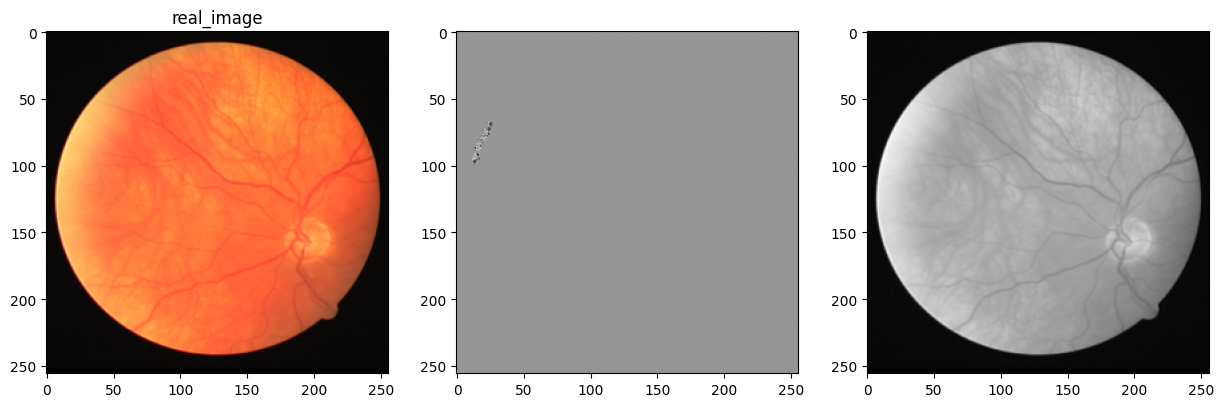

In [27]:
import random

rand_num = random.randint(0 , len(dataset)-1)
image , mask = dataset[rand_num]
image = image.unsqueeze(0)
mask = mask.unsqueeze(0)

image = image.to(device)
mask = mask.to(device)

model.eval()
with torch.no_grad():
  model.reset_state()
  output_mask_test = model(image)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("real_image")
plt.imshow(image.squeeze().permute(1, 2, 0).cpu().numpy()) # Permute dimensions for displaying color image


plt.subplot(1,3,2)
plt.imshow(output_mask_test.squeeze().cpu().numpy() , cmap='gray') # Display mask as grayscale

plt.subplot(1,3,3)
plt.imshow(mask.squeeze().cpu().numpy() , cmap='gray') # Display mask as grayscale

print(image.shape , output_mask_test.shape , mask.shape)